In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv("Datasets/wine_quality.csv")
print(df.head(3))

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    12.87        4.61  2.48               21.5       86.0           1.70   
1    13.28        1.64  2.84               15.5      110.0           2.60   
2    12.82        3.37  2.30               19.5       88.0           1.48   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        0.65                  0.47             0.86             7.65  0.54   
1        2.68                  0.34             1.36             4.60  1.09   
2        0.66                  0.40             0.97            10.26  0.72   

   od280/od315_of_diluted_wines  proline quality_label  
0                          1.86      NaN           low  
1                          2.78    880.0          high  
2                          1.75    685.0           low  


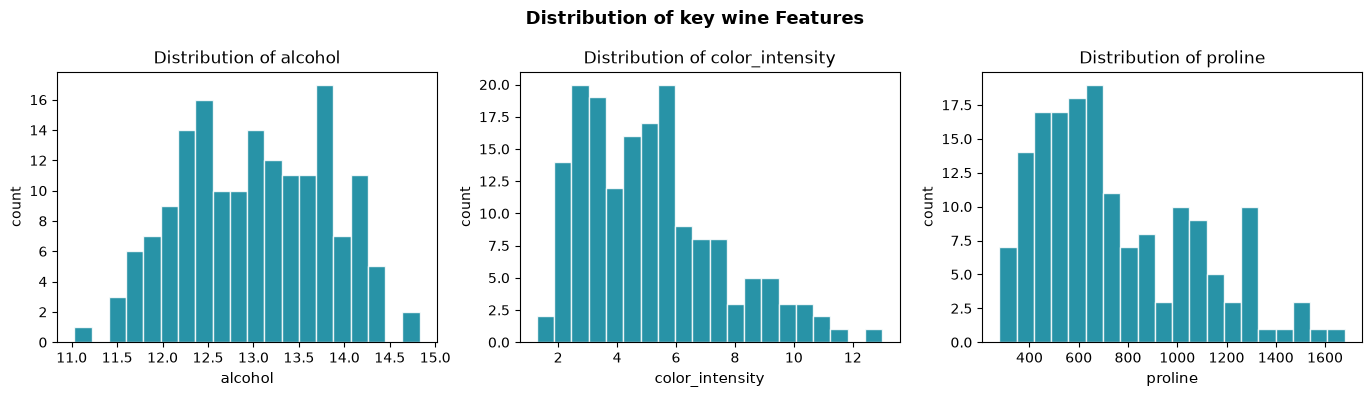

In [4]:
#bins alpla --> histogram
fig, axes= plt.subplots(1,3, figsize= (14,4))
fig.suptitle("Distribution of key wine Features", fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["alcohol", "color_intensity", "proline"]):
    ax.hist(df[col], bins=20, color= "#028098", edgecolor="white", alpha=0.85)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("count")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [5]:
#when to use bar chart and hitogram , multivarate and unovarate 
'''Use a bar chart for comparing categories. Use a histogram for understanding the distribution of continuous numerical data.'''

avg_alcohol=df.groupby("quality_label")["alcohol"].mean().sort_values(ascending=False)
bars=ax.bar(avg_alcohol.index, avg_alcohol.values, color=["#02C39A", "#028090", "#082545"], edgecolor="white", width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.85, f"{bar.get_height(): .2f}", ha="center", va="bottom", fontsize=11)

ax.set_title("Average alcohol content by quality label", fontsize=12)
ax.set_xlabel("quality label")
ax.set_ylabel("Mean alcohao %")
ax.set_ylim(0,15)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

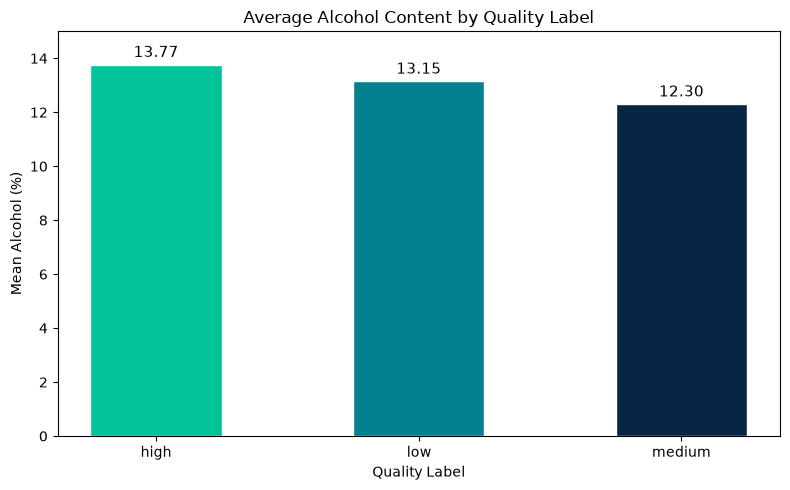

In [6]:
avg_alcohol = (
    df.groupby("quality_label")["alcohol"].mean().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    avg_alcohol.index,
    avg_alcohol.values,
    color=["#02C39A", "#028090", "#082545"],
    edgecolor="white",
    width=0.5
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Average Alcohol Content by Quality Label", fontsize=12)
ax.set_xlabel("Quality Label")
ax.set_ylabel("Mean Alcohol (%)")
ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

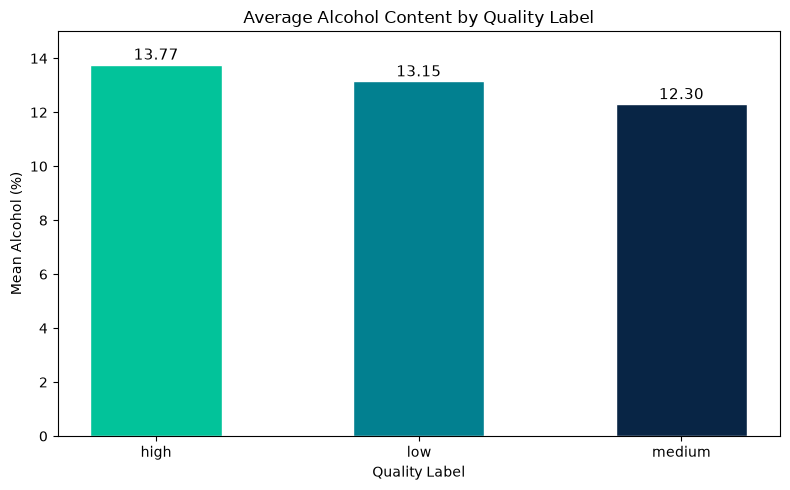

In [7]:
avg_alcohol = (
    df.groupby("quality_label")["alcohol"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    avg_alcohol.index,
    avg_alcohol.values,
    color=["#02C39A", "#028090", "#082545"],
    edgecolor="white",
    width=0.5
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Average Alcohol Content by Quality Label", fontsize=12)
ax.set_xlabel("Quality Label")
ax.set_ylabel("Mean Alcohol (%)")
ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

# **3: Scatter Plot**

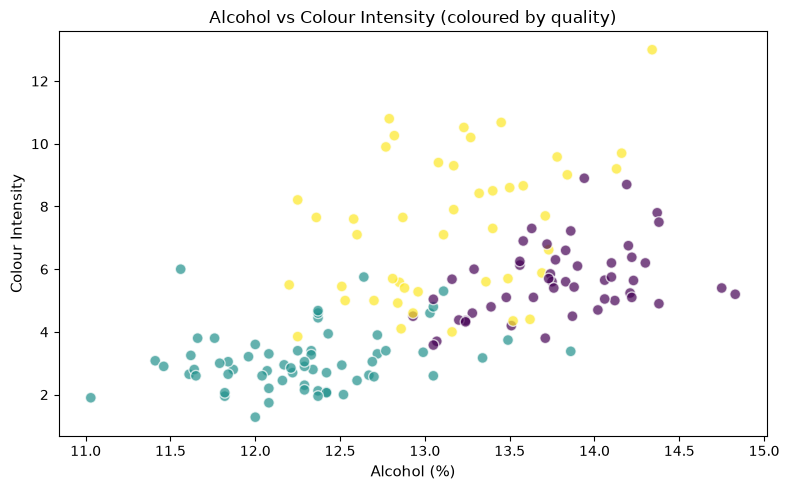

In [8]:
colour_map = {"high": 0, "medium": 1, "low": 2}
colours = df["quality_label"].map(colour_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["alcohol"], df["color_intensity"], c=colours, cmap="viridis", alpha=0.7, edgecolors="white", s=60)

ax.set_xlabel("Alcohol (%)", fontsize=11)
ax.set_ylabel("Colour Intensity", fontsize=11)
ax.set_title("Alcohol vs Colour Intensity (coloured by quality)", fontsize=12)

plt.tight_layout()

plt.show()

# **B.1 - Seaborn**

In [9]:
import seaborn as sns

/tmp/ipykernel_12278/3278525970.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="quality_label", y="alcohol", order=order, palette="Set2",ax=axes[0])
/tmp/ipykernel_12278/3278525970.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="quality_label", y="proline", order=order, palette="Set2",ax=axes[1])


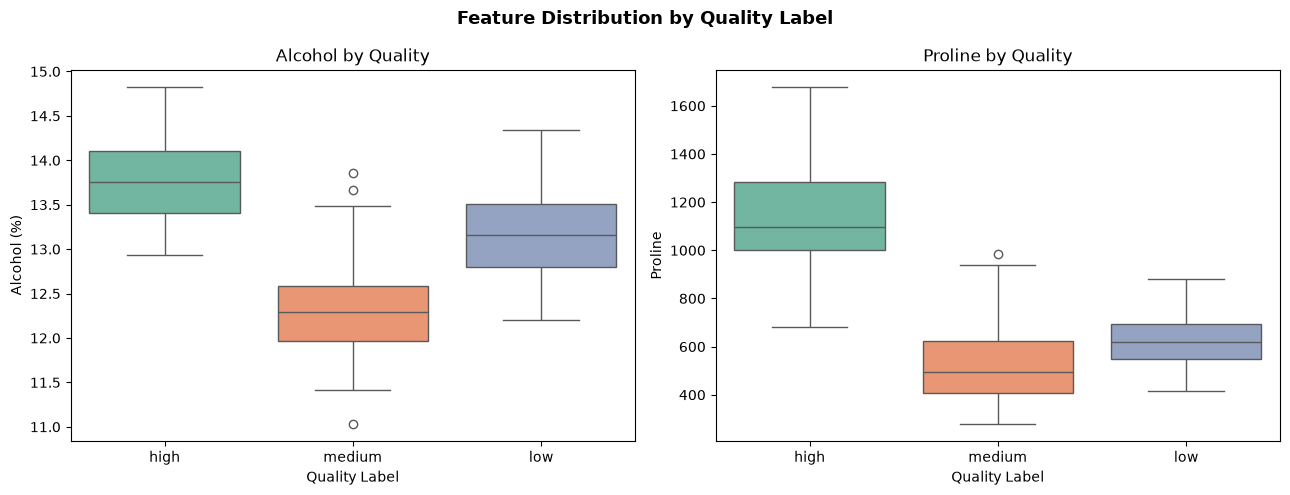

In [10]:
fig, axes = plt.subplots(1, 2, figsize= (13,5))
fig.suptitle("Feature Distribution by Quality Label", fontsize=13, fontweight="bold")

order = ["high", "medium", "low"]

sns.boxplot(data=df, x="quality_label", y="alcohol", order=order, palette="Set2",ax=axes[0])

axes[0].set_title("Alcohol by Quality")
axes[0].set_xlabel("Quality Label")
axes[0].set_ylabel("Alcohol (%)")

sns.boxplot(data=df, x="quality_label", y="proline", order=order, palette="Set2",ax=axes[1])
axes[1].set_title("Proline by Quality")
axes[1].set_xlabel("Quality Label")
axes[1].set_ylabel("Proline")

plt.tight_layout()
plt.show()

# **B.2 - Correlation Heatmap**

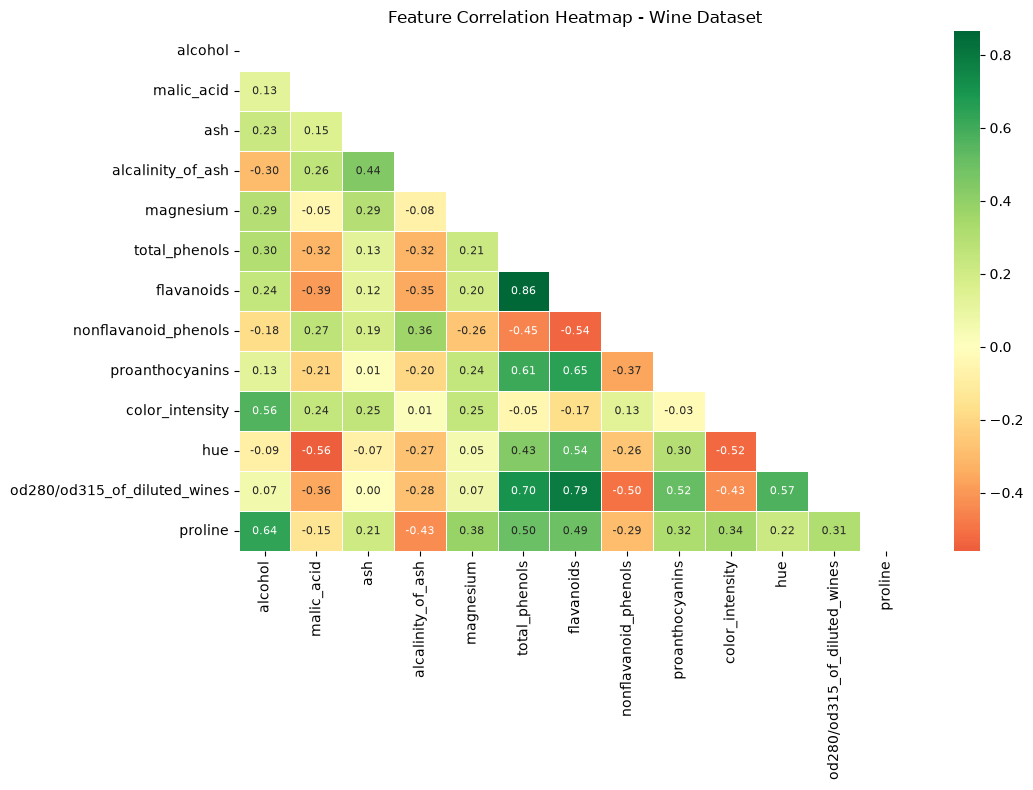

In [11]:
num_df = df.drop(columns=['quality_label'])
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths = 0.4, annot_kws = {"size": 8}, ax = ax)
ax.set_title("Feature Correlation Heatmap - Wine Dataset")

plt.tight_layout()
plt.show()

# **B.3 Pairplot**

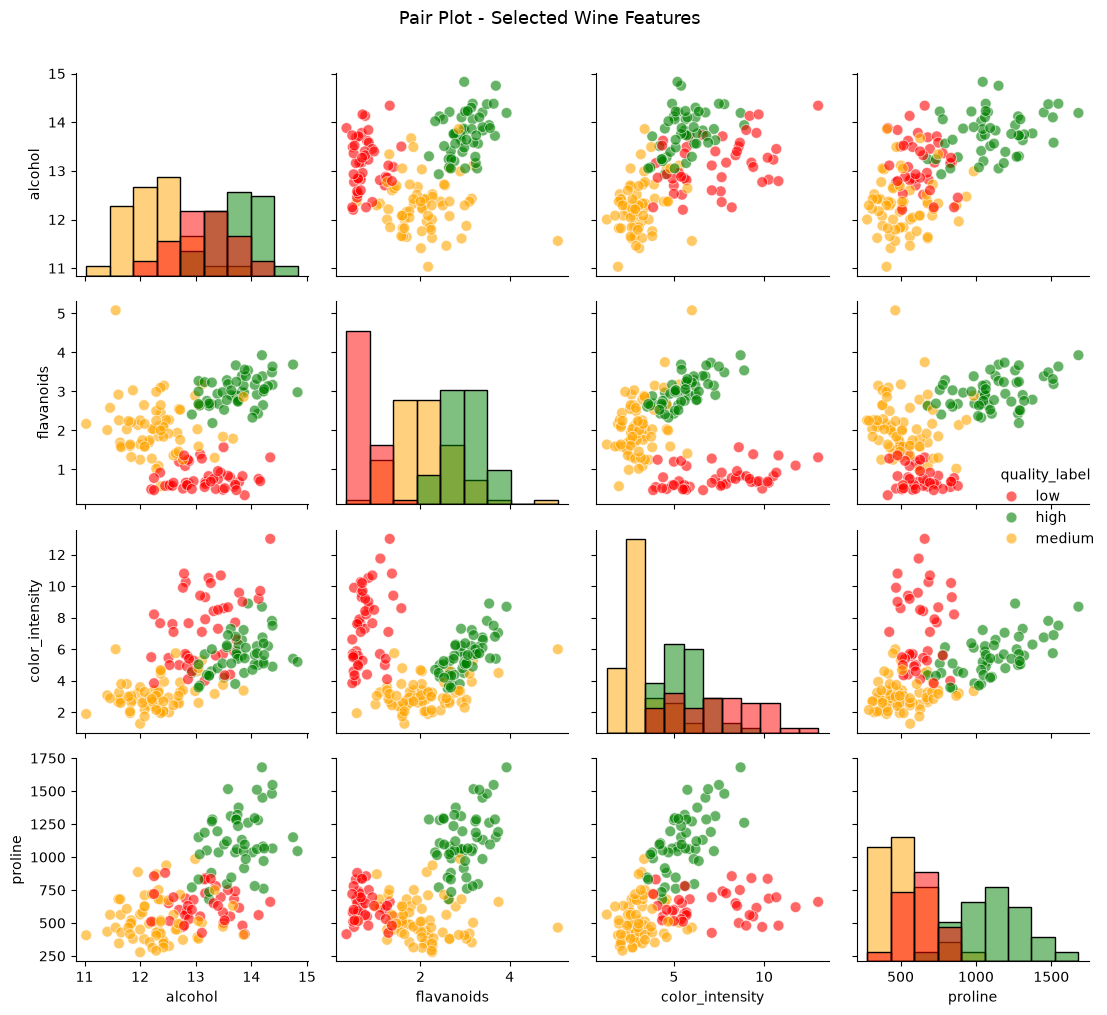

In [12]:
subset = df[["alcohol", "flavanoids", "color_intensity", "proline", "quality_label"]]

pair_plot = sns.pairplot(subset, hue="quality_label", palette={"high":"green", "medium":"orange", "low":"red"},
                         diag_kind="hist", plot_kws={"alpha":0.6, "s":60})

pair_plot.fig.suptitle("Pair Plot - Selected Wine Features", y=1.01, fontsize=13)

plt.tight_layout()
plt.show()

# **C.1 Encoding**

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()
df['quality_le'] = le.fit_transform(df['quality_label'])

print("Label Encoder Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label Encoder Mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [15]:
# Manual Ordering

order_map = {"low": 0, "medium": 1, "high": 2}
df['quality_ordinal'] = df['quality_label'].map(order_map)

print("Manual ordinal mapping: ", order_map)

Manual ordinal mapping:  {'low': 0, 'medium': 1, 'high': 2}


In [16]:
df_ohe = pd.get_dummies(df, columns=['quality_label'], drop_first=True)
new_cols = [c for c in df_ohe.columns if "quality_label" in c]

print("OHE new cols:\n", *new_cols)
print(f"Shape before OHE {df.shape} | after: {df_ohe.shape}")

df[["quality_label", "quality_le", "quality_ordinal"]].drop_duplicates().sort_values("quality_ordinal")

OHE new cols:
 quality_label_low quality_label_medium
Shape before OHE (178, 16) | after: (178, 17)


,quality_label,quality_le,quality_ordinal
0,low,1,0
4,medium,2,1
1,high,0,2


# **D.1 Ratio Features**

In [17]:
df_eng = df.copy()

df_eng["alcohol_acidity_ratio"] = df_eng["alcohol"] / (df_eng['malic_acid'] + 1e-6)

df_eng['flavanoid_phenol_ratio'] = df_eng['flavanoids'] / (df_eng['total_phenols'] + 1e-6)

df_eng['color_per_alcohol'] = df_eng['color_intensity'] / (df['alcohol'] + 1e-6)

df_eng[["alcohol_acidity_ratio", "flavanoid_phenol_ratio", 'color_per_alcohol']].head(10)

,alcohol_acidity_ratio,flavanoid_phenol_ratio,color_per_alcohol
0,2.791756,0.382353,0.594406
1,8.097556,1.030769,0.346386
2,3.804153,0.445946,0.800312
3,5.343094,0.366906,0.775254
4,8.124178,1.149635,0.316975
5,3.577464,0.705882,0.393701
6,5.036733,0.824218,0.226904
7,NaN,1.111570,NaN
8,NaN,0.962069,NaN
9,2.751515,0.400000,0.323054


# D.2 Binning

In [18]:
# Bin alcohol into categories
df_eng["alcohol_bins"] = pd.cut(df_eng["alcohol"], 3, labels = ["low", "medium", "high"])

# Showing distribution
print(df_eng["alcohol_bins"].value_counts())

# Compare alcohol vs quality
pd.crosstab(df_eng["alcohol_bins"], df_eng["quality_label"])

alcohol_bins
medium    81
high      48
low       37
Name: count, dtype: int64


quality_label,high,low,medium
alcohol_bins,,,
low,0,3,34
medium,18,33,30
high,35,11,2
